In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve,
    confusion_matrix,
    RocCurveDisplay,
)
from xgboost import XGBClassifier


In [52]:
# 1. 경로 설정
feat_path = r"D:\ADNI\feature\hippo_features_clean.csv"
adni_path = r"D:\ADNI\metadata\ADNIMERGE_23Sep2025.csv"
out_dir   = r"D:\ADNI\feature"
os.makedirs(out_dir, exist_ok=True)

out_feat_path = os.path.join(out_dir, "hippo_features_clean_icv.csv")

# 2. 피처 / ADNIMERGE 로드
feat = pd.read_csv(feat_path)
adni = pd.read_csv(adni_path, low_memory=False)

print("\n[ 기본 정보 ]")
print(f"피처 행 수     : {len(feat)}")
print(f"ADNIMERGE 행 수: {len(adni)}")

# 3. ADNIMERGE baseline + 임상 + ICV 추출
if "VISCODE" in adni.columns:
    adni_bl = adni[adni["VISCODE"] == "bl"].copy()
else:
    adni_bl = adni.copy()

candidate_cols = ["PTID", "DX_bl", "AGE", "PTGENDER", "APOE4", "ICV", "ICV_bl"]
existing_cols  = [c for c in candidate_cols if c in adni_bl.columns]

adni_bl = adni_bl[existing_cols].dropna(subset=["DX_bl"])
adni_bl = adni_bl.drop_duplicates(subset=["PTID"]).reset_index(drop=True)

print(f"\nBaseline 행 수 : {len(adni_bl)}")
print("DX_bl 분포:")
print(adni_bl["DX_bl"].value_counts())


[ 기본 정보 ]
피처 행 수     : 482
ADNIMERGE 행 수: 16421

Baseline 행 수 : 2419
DX_bl 분포:
LMCI    690
CN      542
EMCI    423
AD      411
SMC     353
Name: DX_bl, dtype: int64


In [53]:
# 4. ICV 사용값 결정 (ICV_bl 우선, 없으면 ICV)
if "ICV_bl" in adni_bl.columns or "ICV" in adni_bl.columns:
    adni_bl["ICV_use"] = np.nan
    if "ICV_bl" in adni_bl.columns:
        adni_bl["ICV_use"] = adni_bl["ICV_bl"]
    if "ICV" in adni_bl.columns:
        adni_bl["ICV_use"] = adni_bl["ICV_use"].fillna(adni_bl["ICV"])
else:
    raise RuntimeError("ADNIMERGE에 ICV/ICV_bl 컬럼이 없습니다.")

# ICV 없는 샘플 제거 (필요시)
adni_bl = adni_bl.dropna(subset=["ICV_use"])

# 5. subject_id ↔ PTID 매칭 + ICV 보정 피처 계산
merged = feat.merge(adni_bl, left_on="subject_id", right_on="PTID", how="inner")

merged["left_hipp_vol_icv_norm"]  = merged["left_hipp_vol_mm3"]  / merged["ICV_use"]
merged["right_hipp_vol_icv_norm"] = merged["right_hipp_vol_mm3"] / merged["ICV_use"]
merged["total_hipp_vol_icv_norm"] = merged["total_hipp_vol_mm3"] / merged["ICV_use"]

print(f"\n매칭 후 샘플 수: {len(merged)}")
print("매칭된 DX_bl 분포:")
print(merged["DX_bl"].value_counts())

# 6. CN / AD만 사용해서 이진 레이블 생성
label_map  = {"CN": 0, "AD": 1}
merged_bin = merged[merged["DX_bl"].isin(label_map.keys())].copy()
merged_bin["label"] = merged_bin["DX_bl"].map(label_map)

print(f"\n이진 분류 샘플 수(CN/AD만): {len(merged_bin)}")
print("레이블 분포:")
print(merged_bin["label"].value_counts())

if len(merged_bin) < 10:
    raise RuntimeError("CN/AD 샘플이 너무 적습니다. DX_bl / 필터를 확인하세요.")

# 7. 성별 인코딩 (PTGENDER → SEX_FEMALE)
if "PTGENDER" in merged_bin.columns:
    merged_bin["SEX_FEMALE"] = (merged_bin["PTGENDER"] == "Female").astype(int)
else:
    merged_bin["SEX_FEMALE"] = np.nan

# 8. 최종 feature CSV 저장 (ICV 보정 포함)
merged_bin.to_csv(out_feat_path, index=False)
print(f"\n[ 저장 완료 ] {out_feat_path}")


매칭 후 샘플 수: 474
매칭된 DX_bl 분포:
CN    296
AD    178
Name: DX_bl, dtype: int64

이진 분류 샘플 수(CN/AD만): 474
레이블 분포:
0    296
1    178
Name: label, dtype: int64

[ 저장 완료 ] D:\ADNI\feature\hippo_features_clean_icv.csv


In [54]:
# 9. 학습에 사용할 피처 선택
feature_cols = [
    "left_hipp_vol_mm3",
    "right_hipp_vol_mm3",
    "total_hipp_vol_mm3",
    "asymmetry_index",
    "left_hipp_vol_icv_norm",
    "right_hipp_vol_icv_norm",
    "total_hipp_vol_icv_norm",
]

if "AGE" in merged_bin.columns:
    feature_cols.append("AGE")
if "APOE4" in merged_bin.columns:
    feature_cols.append("APOE4")

feature_cols.append("SEX_FEMALE")

print("\n[ 사용 피처 목록 ]")
print(feature_cols)

X = merged_bin[feature_cols].copy()
y = merged_bin["label"].copy()

# 결측값은 median으로 채움
X = X.fillna(X.median())

# 10. Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"\nTrain shape: {X_train.shape}")
print(f"Test  shape: {X_test.shape}")


[ 사용 피처 목록 ]
['left_hipp_vol_mm3', 'right_hipp_vol_mm3', 'total_hipp_vol_mm3', 'asymmetry_index', 'left_hipp_vol_icv_norm', 'right_hipp_vol_icv_norm', 'total_hipp_vol_icv_norm', 'AGE', 'APOE4', 'SEX_FEMALE']

Train shape: (379, 10)
Test  shape: (95, 10)


In [55]:
# 11. XGBoost 하이퍼파라미터 튜닝
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    use_label_encoder=False,
    n_jobs=-1,
)

param_dist = {
    "n_estimators":     [300, 400, 500, 700, 900],
    "max_depth":        [3, 4, 5, 6],
    "learning_rate":    [0.005, 0.01, 0.02, 0.03, 0.05],
    "subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma":            [0, 0.5, 1.0],
    "reg_lambda":       [0.5, 1.0, 2.0, 5.0],   # L2 정규화
    "reg_alpha":        [0, 0.5, 1.0],          # L1 정규화
}

print("\n[ 하이퍼파라미터 튜닝 ]")
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)
model = random_search.best_estimator_

print("\n[ Best Hyperparameters ]")
print(random_search.best_params_)


[ 하이퍼파라미터 튜닝 ]
Fitting 5 folds for each of 40 candidates, totalling 200 fits

[ Best Hyperparameters ]
{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 900, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 1.0, 'colsample_bytree': 0.8}


C:\ProgramData\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:42:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [57]:
# 12. 기본 threshold=0.5 평가
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

auc_default = roc_auc_score(y_test, y_prob)
acc_default = accuracy_score(y_test, y_pred_default)

print("\n[ 기본 평가 지표 (Threshold = 0.5) ]")
print(f"AUC       : {auc_default:.4f}")
print(f"Accuracy  : {acc_default:.4f}")
print("\n[ 분류 리포트 (Threshold = 0.5) ]")
print(classification_report(y_test, y_pred_default, target_names=["CN", "AD"]))

# 13. 최적 임계값(Youden J) 탐색 및 재평가
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
J = tpr - fpr
best_idx = np.argmax(J)
best_threshold = thresholds[best_idx]

print(f"\n[ 최적 임계값 (Youden J 기준) ]")
print(f"Optimal threshold: {best_threshold:.3f}")

y_pred_opt = (y_prob >= best_threshold).astype(int)
auc_opt = roc_auc_score(y_test, y_prob)
acc_opt = accuracy_score(y_test, y_pred_opt)
cm_opt  = confusion_matrix(y_test, y_pred_opt)

print("\n[ 평가 지표 (Optimal Threshold 적용) ]")
print(f"AUC       : {auc_opt:.4f}")
print(f"Accuracy  : {acc_opt:.4f}")
print("\n[ 분류 리포트 (Optimal Threshold) ]")
print(classification_report(y_test, y_pred_opt, target_names=["CN", "AD"]))


[ 기본 평가 지표 (Threshold = 0.5) ]
AUC       : 0.9044
Accuracy  : 0.8526

[ 분류 리포트 (Threshold = 0.5) ]
              precision    recall  f1-score   support

          CN       0.89      0.86      0.88        59
          AD       0.79      0.83      0.81        36

    accuracy                           0.85        95
   macro avg       0.84      0.85      0.85        95
weighted avg       0.85      0.85      0.85        95


[ 최적 임계값 (Youden J 기준) ]
Optimal threshold: 0.483

[ 평가 지표 (Optimal Threshold 적용) ]
AUC       : 0.9044
Accuracy  : 0.8526

[ 분류 리포트 (Optimal Threshold) ]
              precision    recall  f1-score   support

          CN       0.91      0.85      0.88        59
          AD       0.78      0.86      0.82        36

    accuracy                           0.85        95
   macro avg       0.84      0.85      0.85        95
weighted avg       0.86      0.85      0.85        95



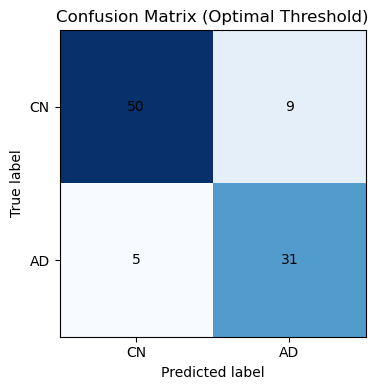

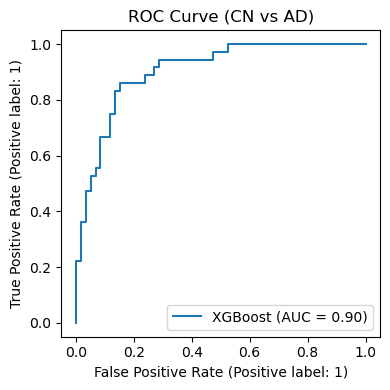

In [58]:
# 14. 시각화: 혼동 행렬(Optimal Threshold) & ROC Curve

# (1) 혼동 행렬
fig_cm, ax_cm = plt.subplots(figsize=(4, 4))
im = ax_cm.imshow(cm_opt, cmap="Blues")

classes = ["CN", "AD"]
ax_cm.set_xticks(np.arange(len(classes)))
ax_cm.set_yticks(np.arange(len(classes)))
ax_cm.set_xticklabels(classes)
ax_cm.set_yticklabels(classes)
ax_cm.set_xlabel("Predicted label")
ax_cm.set_ylabel("True label")
ax_cm.set_title("Confusion Matrix (Optimal Threshold)")

for i in range(cm_opt.shape[0]):
    for j in range(cm_opt.shape[1]):
        ax_cm.text(j, i, cm_opt[i, j],
                   ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

# (2) ROC Curve
fig_roc, ax_roc = plt.subplots(figsize=(4, 4))
RocCurveDisplay.from_predictions(y_test, y_prob, name="XGBoost", ax=ax_roc)
ax_roc.set_title("ROC Curve (CN vs AD)")
plt.tight_layout()
plt.show()

In [60]:
import json
from pathlib import Path

best_xgb = random_search.best_estimator_

output_dir = Path(r"D:\ADNI\model")
output_dir.mkdir(parents=True, exist_ok=True)
model_path = output_dir / "xgb_hippo.json"

best_xgb.save_model(model_path.as_posix())

feature_info = {
    "feature_cols": feature_cols
}

with open(output_dir / "xgb_hippo_features.json", "w", encoding="utf-8") as f:
    json.dump(feature_info, f, ensure_ascii=False, indent=2)

print("모델 저장 완료:", model_path)
print("피처 정보 저장 완료:", output_dir / "xgb_hippo_features.json")


모델 저장 완료: D:\ADNI\model\xgb_hippo.json
피처 정보 저장 완료: D:\ADNI\model\xgb_hippo_features.json
